<a href="https://colab.research.google.com/github/MANOGNA-537/NASSCOM_WEEK1/blob/main/U6_Probability_Statistics_Part1_Lab_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()


Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)



total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())



Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [4]:
# Assuming your DataFrame is named df (typically loaded from the 'tips' dataset)

# 1. Numerical vs categorical columns
# select_dtypes separates columns based on their data types
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# 2. Mean of a numerical column (tip)
# .mean() calculates the average of the specified numerical column
tip_mean = df['tip'].mean()
print(f"\nMean of 'tip' column: {tip_mean}")

# 3. Value counts of a categorical column (sex)
# .value_counts() counts the occurrences of each unique value
sex_counts = df['sex'].value_counts()
print("\nValue counts for 'sex' column:")
print(sex_counts)


Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']

Mean of 'tip' column: 2.99827868852459

Value counts for 'sex' column:
sex
Male      157
Female     87
Name: count, dtype: int64


In [5]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value


Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


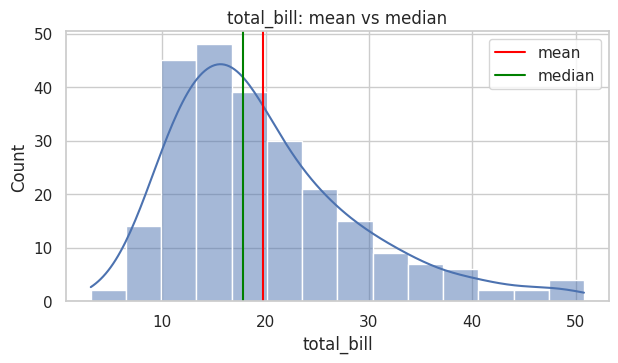

In [6]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()



Mean: 2.99827868852459
Median: 2.9
Mode: 2.0
Is mean > median? True


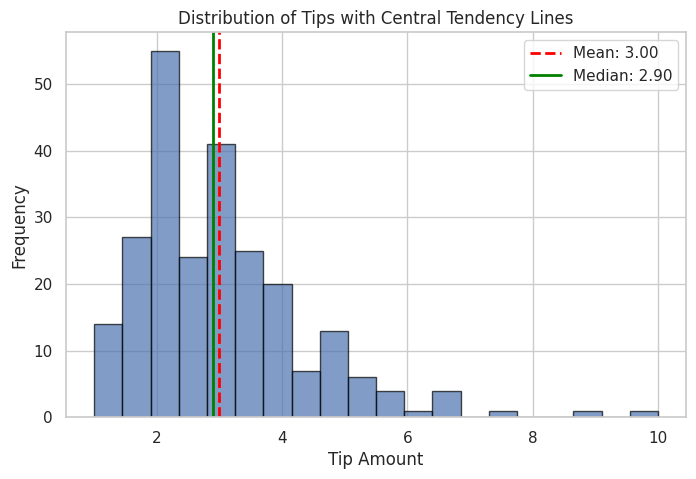

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract the tip series
tip = df["tip"]

# 1. Calculate mean, median, and mode
tip_mean = tip.mean()
tip_median = tip.median()
tip_mode = tip.mode()[0]  # .mode() returns a Series; extract the first value

print(f"Mean: {tip_mean}")
print(f"Median: {tip_median}")
print(f"Mode: {tip_mode}")

# 2. Check whether mean > median (Indicator of right-skewness)
is_right_skewed = tip_mean > tip_median
print(f"Is mean > median? {is_right_skewed}")

# 3. Histogram with mean & median lines
plt.figure(figsize=(8, 5))
plt.hist(tip, bins=20, edgecolor="black", alpha=0.7)

# Add vertical lines for mean and median
plt.axvline(
    tip_mean,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Mean: {tip_mean:.2f}",
)
plt.axvline(
    tip_median,
    color="green",
    linestyle="solid",
    linewidth=2,
    label=f"Median: {tip_median:.2f}",
)

# Labeling the chart
plt.title("Distribution of Tips with Central Tendency Lines")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [8]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)


Range : 47.74
Var   : 79.25
Std   : 8.9


In [9]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')



Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [10]:
import numpy as np
import pandas as pd

tip = df['tip']

# 1. range, variance, std
tip_range = tip.max() - tip.min()
tip_var = tip.var()
tip_std = tip.std()

print(f"Range: {tip_range}")
print(f"Variance: {tip_var}")
print(f"Standard Deviation: {tip_std}")

# 2. Q1, Q3, IQR
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

# 3. Most robust measure of spread = Interquartile Range (IQR)
# The IQR is the most robust measure of spread because it only considers the middle 50%
# of the data. Extreme outliers fall in the lower 25% or upper 25% regions, so they
# do not affect the calculation of Q1, Q3, or the resulting IQR. Conversely, the range,
# variance, and standard deviation rely heavily on extreme values or individual deviations
# from the mean, making them highly sensitive to outliers.


Range: 9.0
Variance: 1.9144546380624725
Standard Deviation: 1.3836381890011826
Q1: 2.0
Q3: 3.5625
IQR: 1.5625


In [11]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))



min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


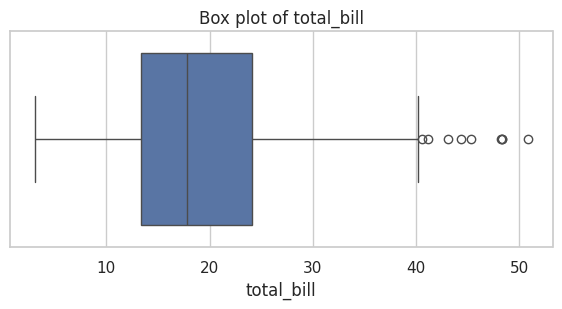

In [12]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()
